# Vino Verde 🍷🍷

1. Import usual libraries

In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.model_selection import cross_val_score
import seaborn as sns


2. Download the dataset from the following url: `"https://full-stack-bigdata-datasets.s3.eu-west-3.amazonaws.com/Machine+Learning+Supervis%C3%A9/R%C3%A9gression+logistique+Cross+validation/Datasets/winequality-red.csv"`

You'll find a description of the variables [here](https://www.kaggle.com/uciml/red-wine-quality-cortez-et-al-2009) where you'll find a description of the variables. Display the first few lines of the dataset.

In [3]:
data = pd.read_csv("https://full-stack-bigdata-datasets.s3.eu-west-3.amazonaws.com/Machine+Learning+Supervis%C3%A9/R%C3%A9gression+logistique+Cross+validation/Datasets/winequality-red.csv")
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


2.bis Transform all variable names so that all spaces are replaced with "_".

In [4]:
data.columns = data.columns.str.replace(" ", "_")
data.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


3. Use a command to get the variable type of each variable in the dataset as well as potential number of missing values.

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         1599 non-null   float64
 1   volatile_acidity      1599 non-null   float64
 2   citric_acid           1599 non-null   float64
 3   residual_sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free_sulfur_dioxide   1599 non-null   float64
 6   total_sulfur_dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


4. Plot the distributions of each of the explanatory variables against the target variable and analyse what you see. Which features seem important to estimate the wine quality?

In [47]:
cat_order = {
    "quality": [3, 4, 5, 6, 7, 8],
}

def display_distrib(f):
    fig = px.histogram(data, f, color = 'quality', facet_row = 'quality', histnorm = 'probability', category_orders = cat_order)
    fig.update_layout(title_text=f"Distribution de '{f}' par classe de qualité")
    fig.update_layout(height=800, width=800)
    fig.show()

display_distrib('fixed_acidity')

In [48]:
display_distrib('volatile_acidity')

In [49]:
display_distrib('citric_acid')

In [50]:
display_distrib('residual_sugar')

In [51]:
display_distrib('chlorides')

In [52]:
display_distrib('free_sulfur_dioxide')

In [53]:
display_distrib('total_sulfur_dioxide')

In [54]:
display_distrib('density')

In [55]:
display_distrib('pH')

In [56]:
display_distrib('sulphates')

In [57]:
display_distrib('alcohol')

In [58]:
display_distrib('fixed_acidity')

5. Is the target variable uniformely distributed across all possible values? Is it possible to use logistic regression to predict the values of quality? How?

In [59]:
data['quality'].value_counts()

quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64

6. Create a baseline model (univariate logistic regression). Take one feature that seems to be a good predictor for the wine quality. What's the model accuracy on train/test sets?

Hint: if some preprocessings are necessary, apply it to X_train/X_test

In [ ]:
target = 'quality'
univariable_list = ['alcohol']

X = data.loc[:, univariable_list]
y = data.loc[:, target]

print(X.head())
print(y.head())

   alcohol
0      9.4
1      9.8
2      9.8
3      9.8
4      9.4
0    5
1    5
2    5
3    6
4    5
Name: quality, dtype: int64


In [76]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [77]:
preprocessor = StandardScaler()
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)
print(X_train[:5])
print(X_test[:5])

[[-0.95579434]
 [-0.76727388]
 [ 0.17532846]
 [ 2.34331382]
 [ 0.36384892]]
[[ 0.36384892]
 [-0.76727388]
 [ 1.21219102]
 [-0.39023294]
 [-0.01319201]]


In [78]:
baseline = LogisticRegression()
baseline.fit(X_train, y_train)

LogisticRegression()

In [79]:
print(baseline.score(X_train, y_train))
print(baseline.score(X_test, y_test))

0.5465207193119624
0.578125


7. Use cross-validation with cv=10 to get a better feel of the model's average performance on this dataset.

In [82]:
score = cross_val_score(baseline, X_train, y_train, cv=10)
print(score.mean())
print(score.std())

0.5410617618110236
0.027051325500817094


/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_split.py:776: UserWarning:

The least populated class in y has only 8 members, which is less than n_splits=10.



8. What would be the test accuracy for a "dummy" model that would always predict the most frequent class? Is the baseline model interesting?

In [83]:
Y_test_pred_dummy = [5]*len(y_test)
print("dummy accuracy on test set : ", accuracy_score(y_test, Y_test_pred_dummy))

dummy accuracy on test set :  0.421875


9. Train a multivariate model by including all the features and compute its accuracy on train/test.

Hint1: Do the explanatory variables need imputation, encoding or normalization? If so proceed to the necessary transformations. Why is normalization important when using logistic regression?

Hint2: If you get a "convergence warning" while training the model, you might want to increase the value of the argument "max_iter" in the LogisticRegression 🤓

In [86]:
print('row', data.shape[0])

row 1599


In [87]:
data.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [88]:
data.describe(include='all')

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [89]:
(data.isnull().sum() / len(data)) * 100

fixed_acidity           0.0
volatile_acidity        0.0
citric_acid             0.0
residual_sugar          0.0
chlorides               0.0
free_sulfur_dioxide     0.0
total_sulfur_dioxide    0.0
density                 0.0
pH                      0.0
sulphates               0.0
alcohol                 0.0
quality                 0.0
dtype: float64

In [92]:
feature_list = [col for col in data.columns if col != target]

X = data.loc[:, feature_list]
y = data.loc[:, target]
y.head()

0    5
1    5
2    5
3    6
4    5
Name: quality, dtype: int64

In [93]:
X.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4


In [94]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [95]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(X_train[:5])
print(X_test[:5])

[[ 0.21833164  0.88971201  0.19209222  0.30972563 -0.04964208  0.69100692
   1.04293362  1.84669643  1.09349989  0.45822284  1.12317723]
 [-1.29016623 -1.78878251  0.65275338 -0.80507963 -0.45521361  2.38847304
   3.59387025 -3.00449133 -0.40043872 -0.40119696  1.40827174]
 [ 1.49475291 -0.78434707  1.01104539 -0.52637831  0.59927236 -0.95796016
  -0.99174203  0.76865471 -0.07566946  0.51551749 -0.58738978]
 [ 0.27635078  0.86181102 -0.06383064 -0.66572897 -0.00908493  0.01202048
  -0.71842739  0.08948842  0.05423824 -1.08873281 -0.96751578]
 [ 0.04427419  2.81487994 -0.62686095  2.39998549 -0.31326357 -0.47296984
   0.2229897   1.1998714   0.37900751 -0.9741435  -0.49235828]]
[[-3.61859850e-01  1.64286407e-01 -9.85152962e-01 -3.86510130e-02
   5.18158057e-01 -1.81975648e-01 -1.99566462e-02  1.75731759e-01
  -4.65392578e-01 -1.34389336e-04 -7.77452782e-01]
 [-3.03840702e-01 -1.70525408e-01 -5.24491803e-01 -6.65728970e-01
  -1.30756387e-01  4.97010797e-01  1.68066777e+00 -4.17191190e-01

In [96]:
classifier = LogisticRegression(max_iter=1000)
classifier.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [97]:
print(classifier.score(X_train, y_train))
print(classifier.score(X_test, y_test))

0.6200156372165755
0.575


10. Is this model significantly better than the baseline?

In [99]:
score = cross_val_score(baseline, X_train, y_train, cv=10,)
print(score.mean())
print(score.std())

/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_split.py:776: UserWarning:

The least populated class in y has only 9 members, which is less than n_splits=10.



0.608347687007874
0.03988409993133184


11. Extract the model's predictions on train/test sets. Use these values to plot the confusion matrices.

In [100]:
Y_train_pred = classifier.predict(X_train)
Y_test_pred = classifier.predict(X_test)

print(Y_train_pred[:5])
print(Y_test_pred[:5])

[6 6 6 5 5]
[5 5 6 5 6]


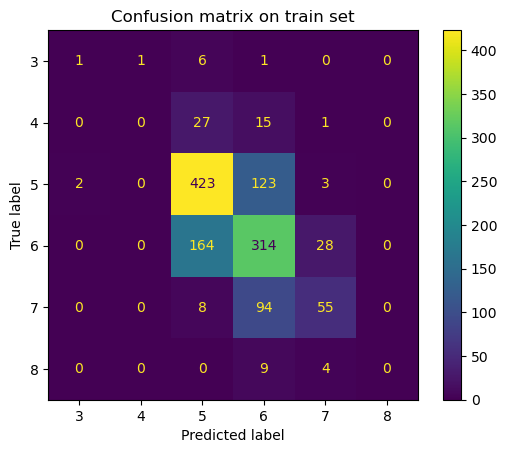

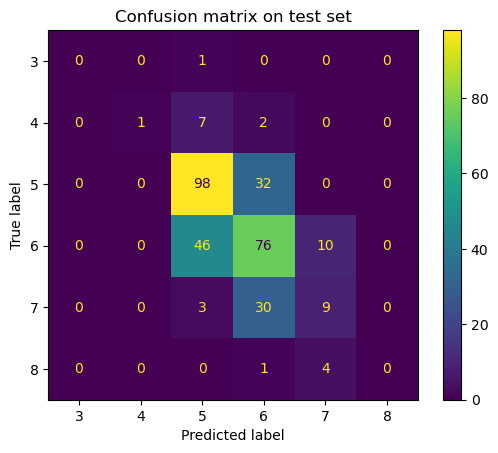

In [102]:
_ , ax = plt.subplots()
ax.set(title='Confusion matrix on train set')
ConfusionMatrixDisplay.from_estimator(classifier, X_train, y_train, ax=ax)
_ , ax = plt.subplots()
ax.set(title='Confusion matrix on test set')
ConfusionMatrixDisplay.from_estimator(classifier, X_test, y_test, ax=ax)

12. Analyze the model's coefficients. Can you deduce easily what are the most important features to predict the wine quality?

In [103]:
classifier.coef_

array([[ 3.25667441e-01,  1.12427312e+00,  1.45177269e-01,
        -1.85376922e-01,  7.38534035e-01,  3.61030897e-01,
        -7.55070727e-01,  7.49767639e-01,  6.52264659e-01,
        -6.51319268e-01, -9.45667195e-01],
       [ 2.26893864e-01,  2.98548538e-01,  7.81986173e-04,
         3.47657734e-01,  2.79196964e-01, -3.75939416e-01,
         2.76340619e-01, -6.79640418e-01,  4.26179571e-01,
        -2.26914801e-01, -6.27478775e-01],
       [-4.40048115e-01, -5.72068668e-03, -5.67297600e-02,
        -1.88257973e-01,  1.22041430e-01, -2.19749827e-01,
         7.89790694e-01,  2.79447747e-01, -1.81491198e-01,
        -3.19285105e-01, -5.61246792e-01],
       [-2.15317462e-01, -4.29313265e-01, -2.61117014e-01,
        -1.69422702e-01,  4.38503359e-04,  7.98482146e-02,
         1.96034885e-01,  2.07169496e-01, -1.53973003e-01,
         7.96050793e-02,  2.70534925e-01],
       [ 2.70469796e-01, -7.99014258e-01, -1.59712338e-01,
         1.98833087e-01, -2.25740659e-01,  8.23374804e-02,
  

In [107]:
coef = pd.DataFrame(index = X.columns, data = classifier.coef_.T, columns = [3, 4, 5, 6, 7, 8])
coef

,3,4,5,6,7,8
fixed_acidity,0.325667,0.226894,-0.440048,-0.215317,0.270470,-0.167666
volatile_acidity,1.124273,0.298549,-0.005721,-0.429313,-0.799014,-0.188773
citric_acid,0.145177,0.000782,-0.056730,-0.261117,-0.159712,0.331600
residual_sugar,-0.185377,0.347658,-0.188258,-0.169423,0.198833,-0.003433
chlorides,0.738534,0.279197,0.122041,0.000439,-0.225741,-0.914470
free_sulfur_dioxide,0.361031,-0.375939,-0.219750,0.079848,0.082337,0.072473
total_sulfur_dioxide,-0.755071,0.276341,0.789791,0.196035,-0.161708,-0.345388
density,0.749768,-0.679640,0.279448,0.207169,-0.316501,-0.240243
pH,0.652265,0.426180,-0.181491,-0.153973,-0.016621,-0.726359
sulphates,-0.651319,-0.226915,-0.319285,0.079605,0.533626,0.584289


13. Use Chi2 test in order to analyse the importance of each variable in your dataset. You may find more information on this test following this link : [scikitlearn](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.chi2.html)

In [109]:
from sklearn.feature_selection import chi2
feature_importance = chi2(X, y)
feature_importance 

(array([1.12606524e+01, 1.55802891e+01, 1.30256651e+01, 4.12329474e+00,
        7.52425579e-01, 1.61936036e+02, 2.75555798e+03, 2.30432045e-04,
        1.54654736e-01, 4.55848775e+00, 4.64298922e+01]),
 array([4.64500416e-02, 8.15035154e-03, 2.31394417e-02, 5.31804675e-01,
        9.79968040e-01, 3.82728810e-33, 0.00000000e+00, 1.00000000e+00,
        9.99526491e-01, 4.72096321e-01, 7.42403757e-09]))

14. Put these values into a DataFrame for more readability.

In [110]:
feature_ranking = pd.DataFrame(columns=X.columns, data=feature_importance, 
                               index=["Chi2 Score", "P-value"]).transpose().sort_values("Chi2 Score")
feature_ranking = feature_ranking.reset_index().rename({'index': 'feature'}, axis = 1)
feature_ranking

,feature,Chi2 Score,P-value
0,density,0.000230,1.000000e+00
1,pH,0.154655,9.995265e-01
2,chlorides,0.752426,9.799680e-01
3,residual_sugar,4.123295,5.318047e-01
4,sulphates,4.558488,4.720963e-01
5,fixed_acidity,11.260652,4.645004e-02
6,citric_acid,13.025665,2.313944e-02
7,volatile_acidity,15.580289,8.150352e-03
8,alcohol,46.429892,7.424038e-09
9,free_sulfur_dioxide,161.936036,3.827288e-33


15. Create a barchart visualization, what can you conclude ?

In [113]:
fig = px.bar(
    feature_ranking,
    y='feature',
    x='Chi2 Score',
    title='Feature Importance based on Chi2 Score',
    labels={'feature': 'Feature', 'Chi2 Score': 'Chi2 Score'},
)
fig.show()

16. Try fitting the same model using the argument class_weight="balanced", what are the consequences on all the aspects of the performances studied before ?

In [114]:
classifier = LogisticRegression(class_weight='balanced')
classifier.fit(X_train, y_train)
print(classifier.score(X_train, y_train))
print(classifier.score(X_test, y_test))

0.4300234558248632
0.43125


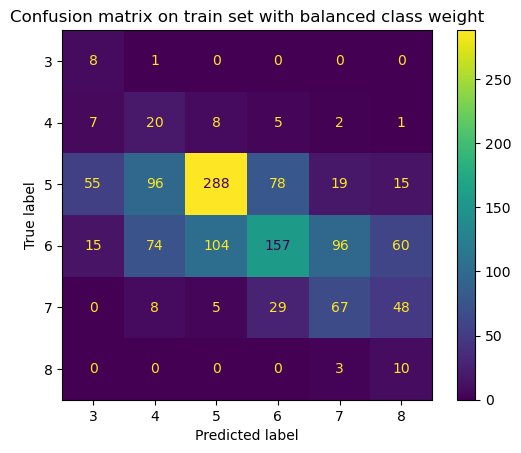

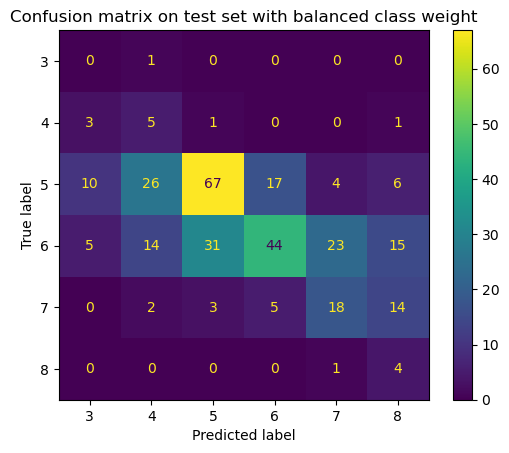

In [115]:
_, ax = plt.subplots()
ax.set(title='Confusion matrix on train set with balanced class weight')
ConfusionMatrixDisplay.from_estimator(classifier, X_train, y_train, ax=ax)
_, ax = plt.subplots()
ax.set(title='Confusion matrix on test set with balanced class weight')
ConfusionMatrixDisplay.from_estimator(classifier, X_test, y_test, ax=ax)

21. As an extra question for which no fixed solution will be proposed, attempt to improve the score using feature engineering (create new variables using common functions, combining variables together in a non-linear way etc...)